In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("kunalgupta2616/dog-vs-cat-images-data")

# print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-vs-cat-images-data' dataset.
Path to dataset files: /kaggle/input/dog-vs-cat-images-data


In [ ]:
# import os
# os.listdir(path)

['dogcat']

In [ ]:
# train=os.path.join(path,"dogcat","train")
# test=os.path.join(path,"dogcat","test1","test1")
# val=os.path.join(path,"dogcat","validation")

In [ ]:
# print(os.listdir(train))
# print(os.listdir(test))
# (os.listdir(val))

['dogs', 'cats']
['7981.jpg', '6234.jpg', '1269.jpg', '3863.jpg', '6241.jpg', '10304.jpg', '623.jpg', '2193.jpg', '11925.jpg', '3750.jpg', '11378.jpg', '2008.jpg', '10730.jpg', '5982.jpg', '7737.jpg', '2081.jpg', '10597.jpg', '6588.jpg', '10054.jpg', '7966.jpg', '3919.jpg', '6197.jpg', '10924.jpg', '6399.jpg', '9960.jpg', '3757.jpg', '9131.jpg', '9620.jpg', '9062.jpg', '4489.jpg', '3138.jpg', '10213.jpg', '3417.jpg', '6074.jpg', '5705.jpg', '8953.jpg', '764.jpg', '5307.jpg', '7894.jpg', '5039.jpg', '10305.jpg', '4407.jpg', '1700.jpg', '1786.jpg', '2907.jpg', '8930.jpg', '11138.jpg', '6324.jpg', '1075.jpg', '4969.jpg', '8983.jpg', '5584.jpg', '10627.jpg', '9697.jpg', '3501.jpg', '10037.jpg', '2863.jpg', '771.jpg', '8352.jpg', '208.jpg', '12167.jpg', '11868.jpg', '4640.jpg', '7222.jpg', '5333.jpg', '4125.jpg', '6560.jpg', '2628.jpg', '10162.jpg', '8104.jpg', '3363.jpg', '4009.jpg', '9645.jpg', '9579.jpg', '820.jpg', '6943.jpg', '3228.jpg', '12132.jpg', '8075.jpg', '6272.jpg', '1789.jpg',

In [ ]:
!mkdir ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d kunalgupta2616/dog-vs-cat-images-data

Dataset URL: https://www.kaggle.com/datasets/kunalgupta2616/dog-vs-cat-images-data
License(s): GPL-2.0
100% 991M/991M [00:50<00:00, 20.4MB/s]



In [ ]:
import zipfile

In [ ]:
with zipfile.ZipFile("dog-vs-cat-images-data.zip", "r") as zip_ref:
    zip_ref.extractall(".")

In [ ]:
import os
print(os.listdir())

['.config', 'dogcat', 'dog-vs-cat-images-data.zip', 'kaggle.json', 'sample_data']


In [ ]:
import os

print("Train cats:", len(os.listdir("/content/dogcat/train/cats")))
print("Train dogs:", len(os.listdir("/content/dogcat/train/dogs")))

print("Validation cats:", len(os.listdir("/content/dogcat/validation/cats")))
print("Validation dogs:", len(os.listdir("/content/dogcat/validation/dogs")))

print("Test:", len(os.listdir("/content/dogcat/test1/test1")))

Train cats: 12500
Train dogs: 12500
Validation cats: 4000
Validation dogs: 4000
Test: 12500


In [ ]:
#lets we select the small amount of data from our data(train) that is 1000-1000 images and it creates other folders
from pathlib import Path
import os

base_dir = Path("/content/dogcat")
small_dir = Path("/content/cats_vs_dogs_small")

for split in ["train", "validation", "test"]:
    for category in ["cats", "dogs"]:
        os.makedirs(small_dir / split / category)

print("New folder structure created.")

New folder structure created.


In [ ]:
#Creating 2000 training images by copying from the training data of our dataset
import shutil

for category in ["cats", "dogs"]:
    source = base_dir / "train" / category
    destination = small_dir / "train" / category

    files = os.listdir(source)[:1000]

    for file in files:
        shutil.copy2(source / file, destination / file)

print("Training data copied.")

Training data copied.


In [ ]:
#Copying 500 validation images
for category in ["cats", "dogs"]:
    source = base_dir / "validation" / category
    destination = small_dir / "validation" / category

    files = os.listdir(source)[1000:1500]

    for file in files:
        shutil.copy2(source / file, destination / file)

print("Validation data copied.")

Validation data copied.


In [ ]:
#copying 1000 test images, different from the training data
for category in ["cats", "dogs"]:
    source = base_dir / "train" / category
    destination = small_dir / "test" / category

    files = os.listdir(source)[1500:2500]

    for file in files:
        shutil.copy2(source / file, destination / file)

print("Test data copied.")

Test data copied.


In [ ]:
#Checking it
for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}")

    for category in ["cats", "dogs"]:
        path = small_dir / split / category
        print(category, ":", len(os.listdir(path)))


TRAIN
cats : 1000
dogs : 1000

VALIDATION
cats : 500
dogs : 500

TEST
cats : 1000
dogs : 1000


In [ ]:
#Creating Our Model
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs) #1. for float values      # we do rescaling for taking our pixel values in a range(0-1) and reduce them by dividing all the vules with 255.
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Configuring the model for training or compiling our model
model.compile(loss="binary_crossentropy",
      optimizer="rmsprop",
      metrics=["accuracy"])

##Proprocessing

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory  #The image_dataset_from_directory(module) also works as a generator

train_dataset = image_dataset_from_directory(
    small_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    small_dir / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    small_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [ ]:
#Checking the shape
for images, labels in train_dataset.take(1):  #take(1) can takes one batch from the training dataset
    print(images.shape)
    print(labels.shape)

(32, 180, 180, 3)
(32,)


In [ ]:
#Another way for checking shape
for data_batch, labels_batch in train_dataset:
  print("data batch shape:", data_batch.shape)
  print("labels batch shape:", labels_batch.shape)
  break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)


In [ ]:
#Fitting Our Model
#By using callbacks
callbacks = [
      keras.callbacks.ModelCheckpoint(
  filepath="convnet_from_scratch.keras",
  save_best_only=True,
  monitor="val_loss")
  ]

In [ ]:
history =model.fit(train_dataset,epochs=30,validation_data=validation_dataset,callbacks=callbacks)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 152ms/step - accuracy: 0.5130 - loss: 0.7005 - val_accuracy: 0.6210 - val_loss: 0.6897
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5580 - loss: 0.6925 - val_accuracy: 0.5260 - val_loss: 0.6859
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.5855 - loss: 0.6777 - val_accuracy: 0.5320 - val_loss: 0.6881
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.6145 - loss: 0.6568 - val_accuracy: 0.6740 - val_loss: 0.6338
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6425 - loss: 0.6338 - val_accuracy: 0.7000 - val_loss: 0.5882
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.6725 - loss: 0.6124 - val_accuracy: 0.6700 - val_loss: 0.5890
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.7095 - loss: 0.5631 - val_accuracy: 0.6810 - val_loss: 0.6268
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7315 - loss: 0.5446 - val_accuracy: 0.6420 -

In [ ]:
test_model = keras.models.load_model("/content/convnet_from_scratch.keras")  #It gets our best model
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.7070 - loss: 0.5535
Test accuracy: 0.707


In [ ]:
#Because our Model is Overfit,So we can use data augmentation there
#First we define layers for zoom,rotation and random flip of our images.
data_augmentation = keras.Sequential(
    [
      layers.RandomFlip("horizontal"),
      layers.RandomRotation(0.1),
      layers.RandomZoom(0.2),
    ]
)

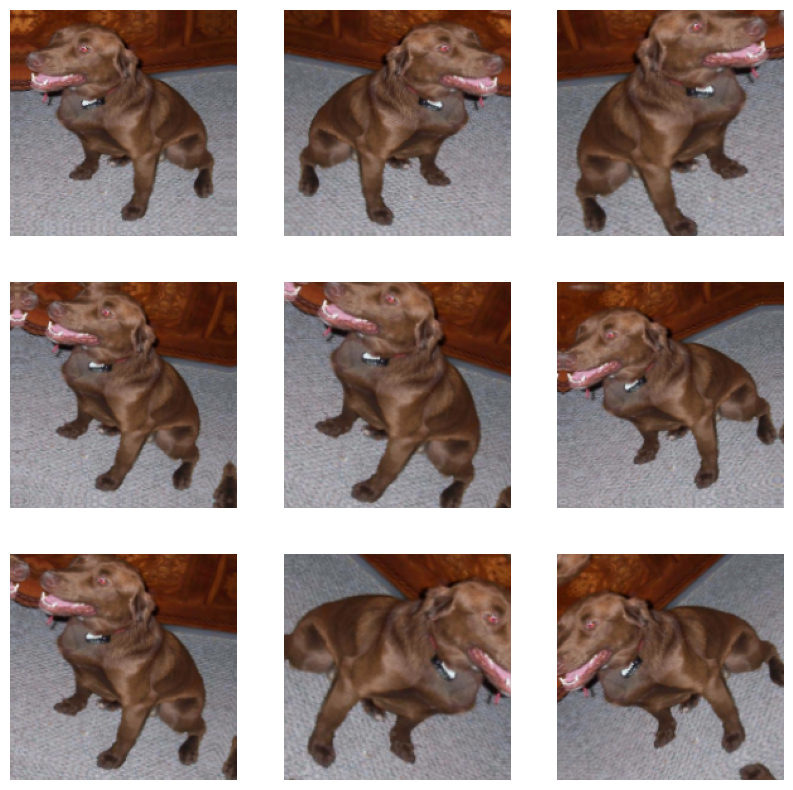

In [ ]:
#The exmample of our augmented sample image
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [ ]:
#Lets we defining a new CNN(convnet), After applying the augmentation
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)  # data_augmentation is defined above
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,982,084 (7.56 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 991,043 (3.78 MB)

In [ ]:
#Compiling our model
model.compile(loss="binary_crossentropy",
      optimizer="rmsprop",
      metrics=["accuracy"])

In [ ]:
#Saving our best result in our data,Through callback
callbacks = [
      keras.callbacks.ModelCheckpoint(
      filepath="convnet_from_scratch_with_augmentation.keras",
      save_best_only=True,
      monitor="val_loss")
    ]

In [ ]:
#Fitting Our Model
history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.5040 - loss: 0.6991 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.5010 - loss: 0.6944 - val_accuracy: 0.5030 - val_loss: 0.6913
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.5205 - loss: 0.6986 - val_accuracy: 0.5390 - val_loss: 0.6867
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.5450 - loss: 0.6886 - val_accuracy: 0.6600 - val_loss: 0.6762
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6065 - loss: 0.6732 - val_accuracy: 0.5110 - val_loss: 0.7900
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.6380 - loss: 0.6636 - val_accuracy: 0.6430 - val_loss: 0.6377
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.6520 - loss: 0.6293 - val_accuracy: 0.6790 - val_loss: 0.6153
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.6610 - loss: 0.6188 - val_accuracy: 0.

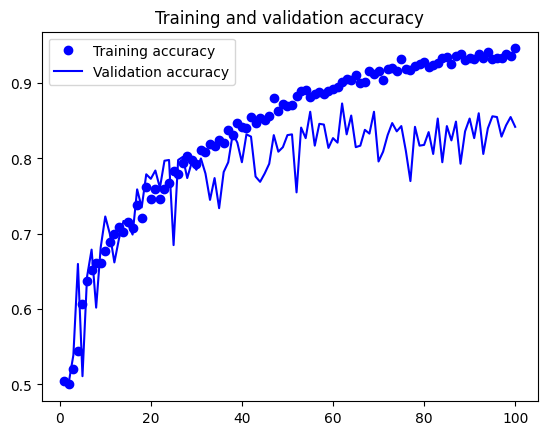

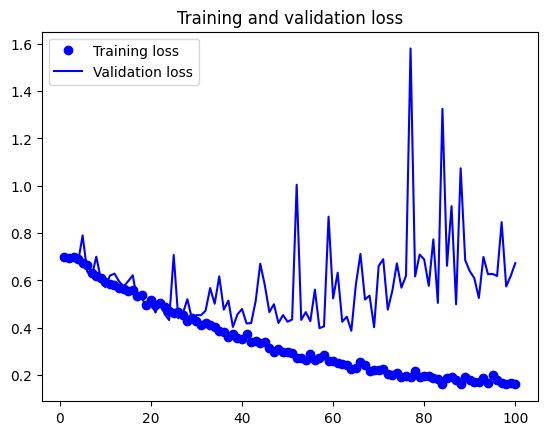

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
#Evaluating the model result on test set
test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8395 - loss: 0.3987
Test accuracy: 0.840


#Batch Normalization
Batch Normalization in Deep Learning

Batch Normalization (BatchNorm) is a technique used to make neural networks train faster and more stably.

Simple idea:

Batch Normalization normalizes the values coming from a layer before passing them to the next layer.

In [ ]:
#Feature Extraction with a pretrained model
#We have multiple models like these
#  Xception
#  ResNet
#  MobileNet
#  EfficientNet
#  DenseNet
import tensorflow as tf
from tensorflow import keras

#Lets we are using vgg16
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Lets we extracting the features of vgg16 and their corresponding labels.

import numpy as np
def get_features_and_labels(dataset):
      all_features = []
      all_labels = []
      for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
      return np.concatenate(all_features), np.concatenate(all_labels)


train_features, train_labels =  get_features_and_labels(train_dataset)
val_features, val_labels =  get_features_and_labels(validation_dataset)
test_features, test_labels =  get_features_and_labels(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
train_features.shape

(2000, 5, 5, 512)

In [ ]:
test_features.shape

(2000, 5, 5, 512)

In [ ]:
#Lets we can defining and training our classifier(densly connected)
from keras import layers

inputs = keras.Input(shape=(5, 5, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)


In [ ]:
#Lets compiling our model
model.compile(loss="binary_crossentropy",
      optimizer="rmsprop",
      metrics=["accuracy"])

In [ ]:
#applying callback for saving the best result
callbacks = [
    keras.callbacks.ModelCheckpoint(
filepath="feature_extraction.keras",
save_best_only=True,
monitor="val_loss")
]

In [ ]:
#Fitting our model
history = model.fit(
    train_features, train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    callbacks=callbacks)

#The model doesn't learn from val_labels. Instead, after each epoch, it uses them to check its performance.

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9180 - loss: 20.6017 - val_accuracy: 0.9540 - val_loss: 9.2900
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9805 - loss: 2.8095 - val_accuracy: 0.9620 - val_loss: 8.1646
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9855 - loss: 2.0531 - val_accuracy: 0.9530 - val_loss: 9.4647
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9860 - loss: 1.9484 - val_accuracy: 0.9610 - val_loss: 8.1054
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9925 - loss: 0.7558 - val_accuracy: 0.9680 - val_loss: 8.4458
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9950 - loss: 1.1347 - val_accuracy: 0.9660 - val_loss: 6.3548
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9935 - loss: 1.1100 - val_accuracy: 0.9710 - val_loss: 7.0321
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9935 - loss: 0.5004 - val_accuracy: 0.9730 - val_los

In [29]:
#Evaluating the model result on test set
test_model = keras.models.load_model("feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features,test_labels)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9750 - loss: 4.6429
Test accuracy: 0.975


##Plotting Our Results

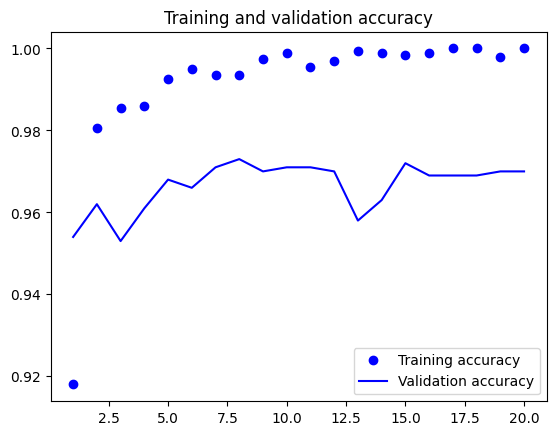

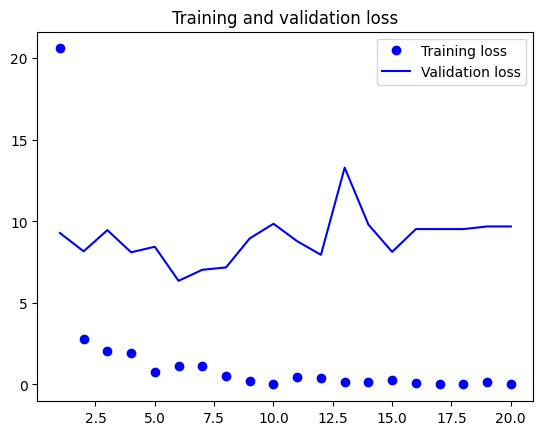

In [30]:
import matplotlib.pyplot as plt
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

###Instantiating and freezing the VGG16 convolutional base

In [32]:
conv_base  = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.trainable = False   #It can stops the training of our model on new data

In [35]:
#Printing the list of trainable weights before and after freezing
conv_base.trainable = True
print("This is the number of trainable weights "
      "before freezing the conv base:", len(conv_base.trainable_weights))
conv_base.trainable = False
print("This is the number of trainable weights "
      "after freezing the conv base:", len(conv_base.trainable_weights))

This is the number of trainable weights before freezing the conv base: 26
This is the number of trainable weights after freezing the conv base: 0


**Now we can create a new model that chains together**

**1 A data augmentation stage**

**2 Our frozen convolutional base**

**3 A dense classifier**

In [44]:
data_augmentation= keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs=keras.Input(shape=(180,180,3))
x=data_augmentation(inputs)
x=keras.applications.vgg16.preprocess_input(x)
x=conv_base(x)
x=layers.Flatten()(x)
x=layers.Dense(256)(x)
x=layers.Dropout(0.5)(x)
outputs=layers.Dense(1,activation="sigmoid")(x)
model=keras.Model(inputs,outputs)
model.compile(loss=("binary_crossentropy"),
              optimizer=("rmsprop"),
              metrics=["accuracy"])


In [45]:
#Lets we finding out best reslt through callback and saves it in the file
callbacks = [
    keras.callbacks.ModelCheckpoint(
filepath="feature_extraction_with_data_augmentation.keras",
save_best_only=True,
monitor="val_loss")
]


In [46]:
#fiting our model
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 245ms/step - accuracy: 0.8925 - loss: 21.1961 - val_accuracy: 0.9360 - val_loss: 11.6187
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.9435 - loss: 7.0783 - val_accuracy: 0.9690 - val_loss: 6.1498
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 0.9555 - loss: 5.9381 - val_accuracy: 0.9570 - val_loss: 9.1175
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.9540 - loss: 6.4571 - val_accuracy: 0.9650 - val_loss: 6.1023
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.9720 - loss: 3.4898 - val_accuracy: 0.9710 - val_loss: 6.9130
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.9690 - loss: 4.1435 - val_accuracy: 0.9500 - val_loss: 10.8899
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 0.9665 - loss: 3.7232 - val_accuracy: 0.9670 - val_loss: 6.2955
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.9680 - loss: 3.6478 - val_a

**Evaluating the results of our model on test dataset**

In [47]:
test_model = keras.models.load_model(
"feature_extraction_with_data_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.9765 - loss: 2.3536
Test accuracy: 0.976


**We freeze all the layers,until the last 4th(means three layers fine tune from 16)**

In [48]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

##Fine Tunning Our Model

In [49]:
#Now we can begin fine-tuning the model. We’ll do this with the RMSprop optimizer,
# using a very low learning rate. The reason for using a low learning rate is that we want to
# limit the magnitude of the modifications we make to the representations of the three
# layers we’re fine-tuning. Updates that are too large may harm these representations.

model.compile(loss="binary_crossentropy",
      optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
      metrics=["accuracy"])



callbacks = [
    keras.callbacks.ModelCheckpoint(
filepath="fine_tuning.keras",
save_best_only=True,
monitor="val_loss")

]




history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 235ms/step - accuracy: 0.9900 - loss: 0.4026 - val_accuracy: 0.9690 - val_loss: 3.7746
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 225ms/step - accuracy: 0.9875 - loss: 0.6284 - val_accuracy: 0.9690 - val_loss: 3.5465
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 201ms/step - accuracy: 0.9905 - loss: 0.3060 - val_accuracy: 0.9730 - val_loss: 3.7482
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - accuracy: 0.9880 - loss: 0.4098 - val_accuracy: 0.9690 - val_loss: 4.0156
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/step - accuracy: 0.9875 - loss: 0.4191 - val_accuracy: 0.9700 - val_loss: 4.0204
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 223ms/step - accuracy: 0.9920 - loss: 0.3267 - val_accuracy: 0.9690 - val_loss: 3.6694
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.9920 - loss: 0.2605 - val_accuracy: 0.9720 - val_loss: 3.8159
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 207ms/step - accuracy: 0.9935 - loss: 0.1698 - val_accu

**Lets evaluating our model results on test data**

In [50]:
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9765 - loss: 1.4158
Test accuracy: 0.976


#Summary:

 Convnets are the best type of machine learning models for computer vision
tasks. It’s possible to train one from scratch even on a very small dataset, with
decent results.
 Convnets work by learning a hierarchy of modular patterns and concepts to
represent the visual world.
 On a small dataset, overfitting will be the main issue. Data augmentation is a
powerful way to fight overfitting when you’re working with image data.
 It’s easy to reuse an existing convnet on a new dataset via feature extraction.
This is a valuable technique for working with small image datasets.
 As a complement to feature extraction, you can use fine-tuning, which adapts to
a new problem some of the representations previously learned by an existing
model. This pushes performance a bit further.
